## Descriptive Analytics for Numerical Columns

In [3]:
import pandas as pd

In [8]:
df = pd.read_csv("sales_data_with_discounts.csv")
print(df.head())

         Date       Day  SKU City  Volume       BU  Brand       Model  \
0  01-04-2021  Thursday  M01    C      15  Mobiles  RealU       RU-10   
1  01-04-2021  Thursday  M02    C      10  Mobiles  RealU   RU-9 Plus   
2  01-04-2021  Thursday  M03    C       7  Mobiles   YouM       YM-99   
3  01-04-2021  Thursday  M04    C       6  Mobiles   YouM  YM-99 Plus   
4  01-04-2021  Thursday  M05    C       3  Mobiles   YouM      YM-98    

   Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      12100             181500          11.654820     21153.498820   
1      10100             101000          11.560498     11676.102961   
2      16100             112700           9.456886     10657.910157   
3      20100             120600           6.935385      8364.074702   
4       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053770  


In [12]:
numerical_col = df.select_dtypes(include=["int64","float64"]).columns
print("Numerical columns : ", numerical_col.tolist())

Numerical columns :  ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']


In [13]:
desc_stats = pd.DataFrame({
    "Mean" : df[numerical_col].mean(),
    "Median" : df[numerical_col].median(),
    "Mode" : df[numerical_col].mode().iloc[0],
    "Standard Deviation" : df[numerical_col].std()
})
print(desc_stats)

                           Mean       Median          Mode  Standard Deviation
Volume                 5.066667     4.000000      3.000000            4.231602
Avg Price          10453.433333  1450.000000    400.000000        18079.904840
Total Sales Value  33812.835556  5700.000000  24300.000000        50535.074173
Discount Rate (%)     15.155242    16.577766      5.007822            4.220602
Discount Amount     3346.499424   988.933733     69.177942         4509.902963
Net Sales Value    30466.336131  4677.788059    326.974801        46358.656624


In [22]:
desc_stats_variability = pd.DataFrame({
    "Mean" : df[numerical_col].mean(),
    "Median" : df[numerical_col].median(),
    "Mode" : df[numerical_col].mode().iloc[0],
    "Standard Deviation" : df[numerical_col].std()
})

desc_stats_variability["CV (%)"] = (desc_stats_variability["Standard Deviation"] / desc_stats_variability["Mean"]) * 100

desc_stats_variability = desc_stats_variability.round(2)

print(desc_stats_variability)

                       Mean   Median      Mode  Standard Deviation  CV (%)
Volume                 5.07     4.00      3.00                4.23   83.52
Avg Price          10453.43  1450.00    400.00            18079.90  172.96
Total Sales Value  33812.84  5700.00  24300.00            50535.07  149.46
Discount Rate (%)     15.16    16.58      5.01                4.22   27.85
Discount Amount     3346.50   988.93     69.18             4509.90  134.76
Net Sales Value    30466.34  4677.79    326.97            46358.66  152.16


In [23]:
def variability_level(cv):
    if cv < 10:
        return "Low"
    elif cv < 30:
        return "Moderate"
    else:
        return "High"

desc_stats_variability["variablity_level"] = desc_stats_variability["CV (%)"].apply(variability_level)
print(desc_stats_variability)
    

                       Mean   Median      Mode  Standard Deviation  CV (%)  \
Volume                 5.07     4.00      3.00                4.23   83.52   
Avg Price          10453.43  1450.00    400.00            18079.90  172.96   
Total Sales Value  33812.84  5700.00  24300.00            50535.07  149.46   
Discount Rate (%)     15.16    16.58      5.01                4.22   27.85   
Discount Amount     3346.50   988.93     69.18             4509.90  134.76   
Net Sales Value    30466.34  4677.79    326.97            46358.66  152.16   

                  variablity_level  
Volume                        High  
Avg Price                     High  
Total Sales Value             High  
Discount Rate (%)         Moderate  
Discount Amount               High  
Net Sales Value               High  


## Data Visualization

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Histogram

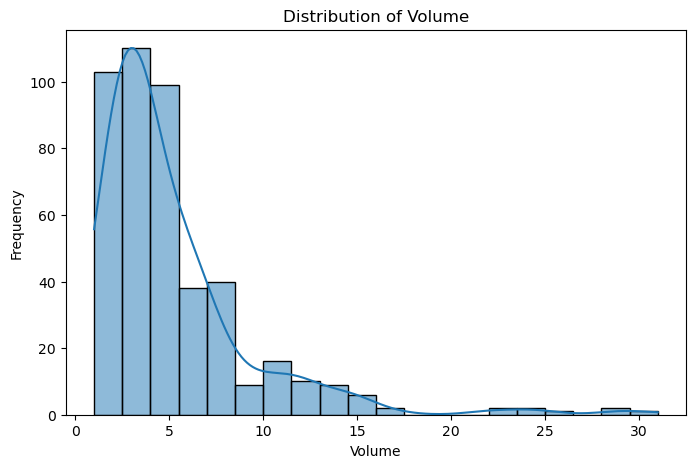

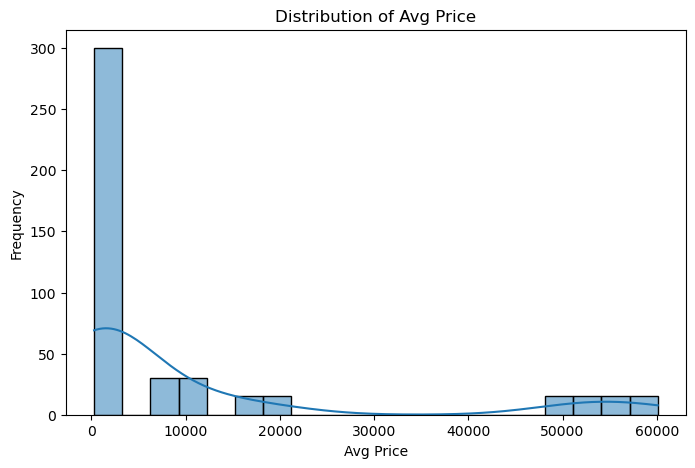

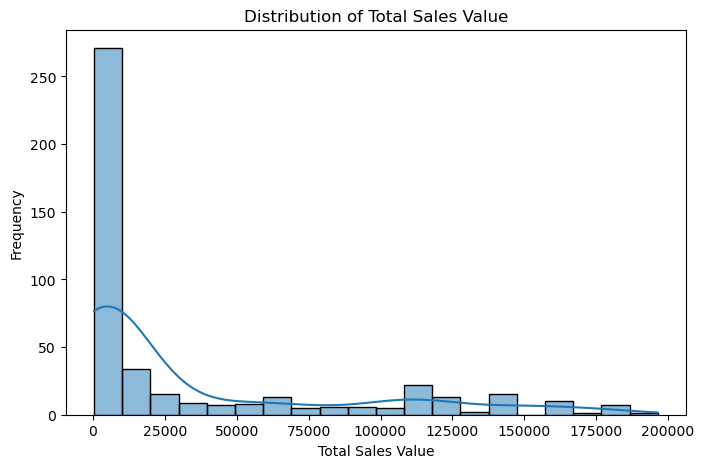

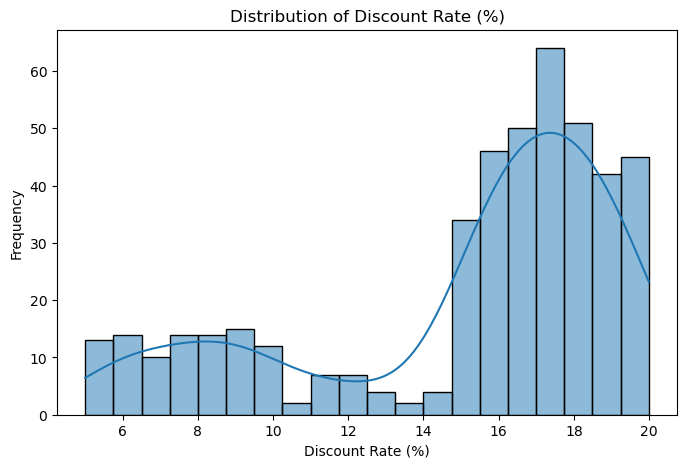

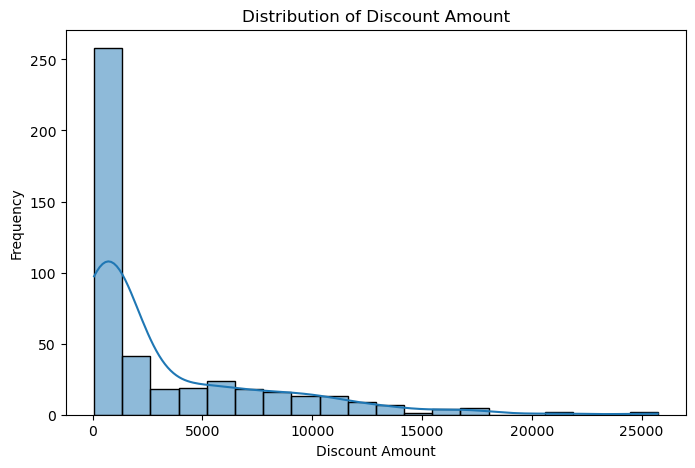

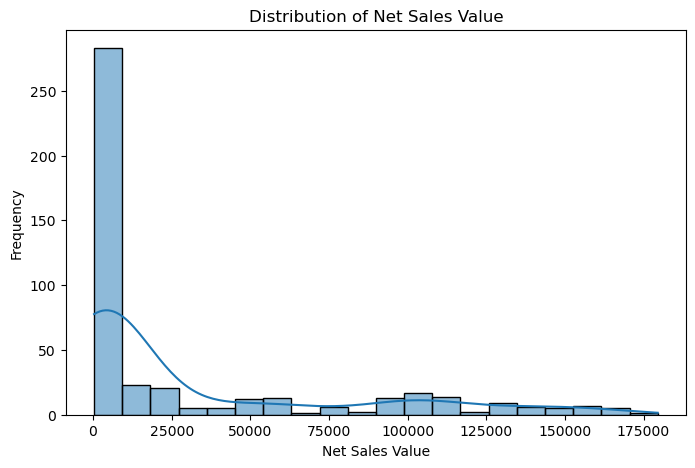

In [30]:
for col in numerical_col:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col],kde=True,bins= 20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### BoxPlot

Text(0.5, 1.0, 'Volume')

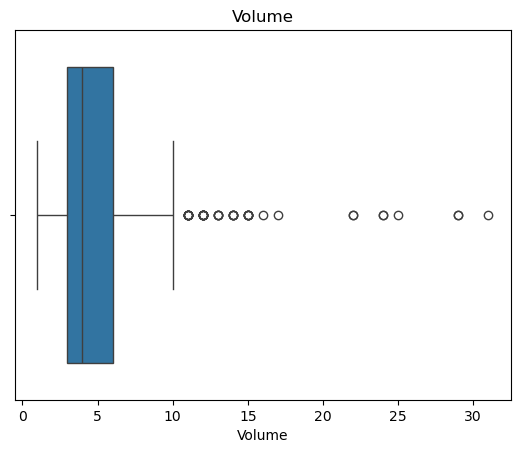

In [32]:
sns.boxplot(data=df,x='Volume')
plt.title('Volume')

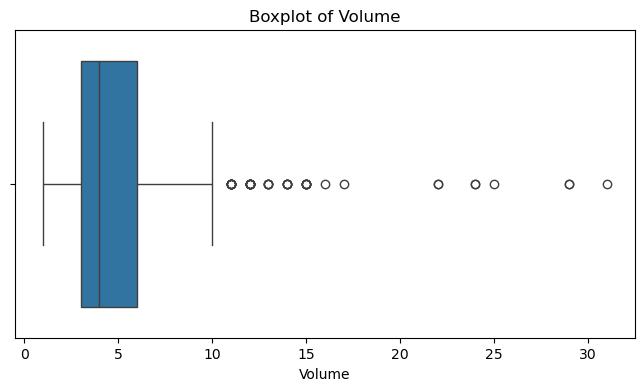

Volume:
  Q1 = 3.00, Q3 = 6.00, IQR = 3.00
  Lower Bound = -1.50, Upper Bound = 10.50
  Number of Outliers = 44



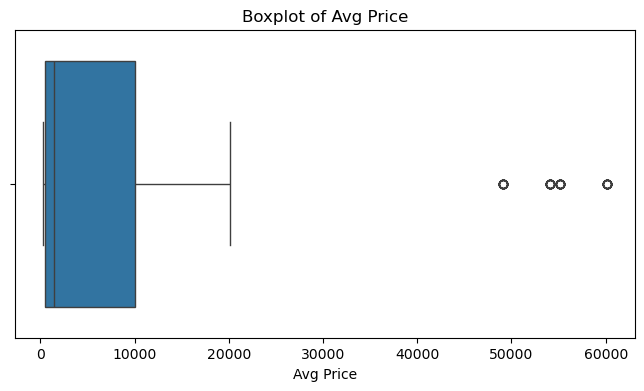

Avg Price:
  Q1 = 465.00, Q3 = 10100.00, IQR = 9635.00
  Lower Bound = -13987.50, Upper Bound = 24552.50
  Number of Outliers = 60



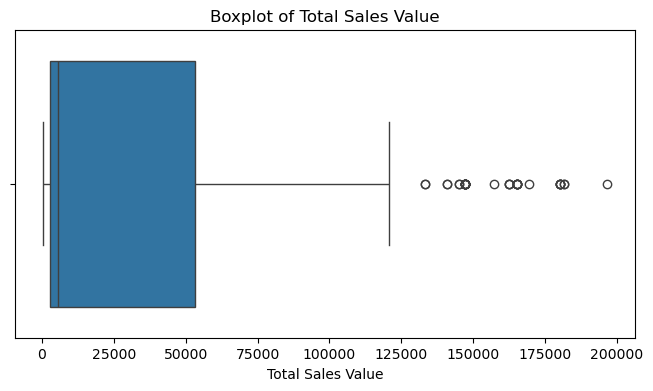

Total Sales Value:
  Q1 = 2700.00, Q3 = 53200.00, IQR = 50500.00
  Lower Bound = -73050.00, Upper Bound = 128950.00
  Number of Outliers = 36



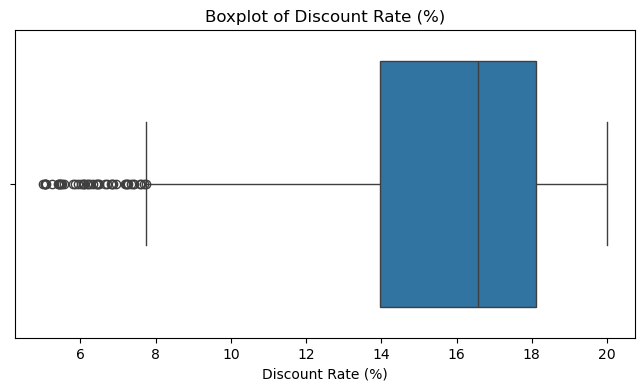

Discount Rate (%):
  Q1 = 13.97, Q3 = 18.11, IQR = 4.15
  Lower Bound = 7.74, Upper Bound = 24.34
  Number of Outliers = 45



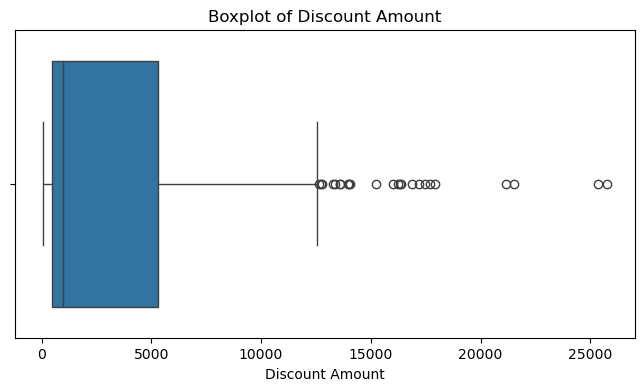

Discount Amount:
  Q1 = 460.46, Q3 = 5316.50, IQR = 4856.04
  Lower Bound = -6823.59, Upper Bound = 12600.55
  Number of Outliers = 24



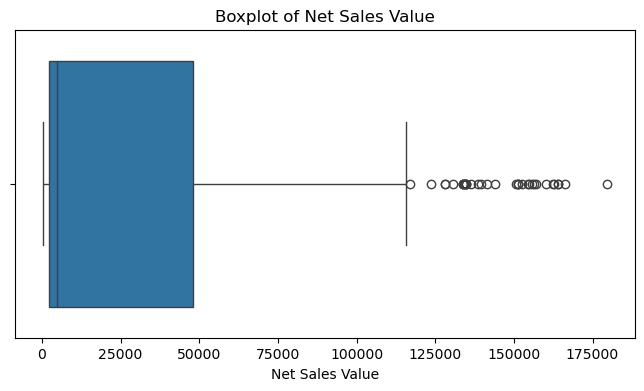

Net Sales Value:
  Q1 = 2202.21, Q3 = 47847.91, IQR = 45645.70
  Lower Bound = -66266.35, Upper Bound = 116316.47
  Number of Outliers = 35



In [41]:
for col in numerical_col:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

    
    Q1 = df[col].quantile(0.25) 
    Q3 = df[col].quantile(0.75)  
    IQR = Q3 - Q1                
    
    lower_bound = Q1 - 1.5 * IQR  
    upper_bound = Q3 + 1.5 * IQR  
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    print(f"{col}:")
    print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  Lower Bound = {lower_bound:.2f}, Upper Bound = {upper_bound:.2f}")
    print(f"  Number of Outliers = {outliers.count()}\n")


    

### Bar chart

In [44]:
categorical_cols = df.select_dtypes(include=["object","category"]).columns
print("Categorical Columns:", categorical_cols.tolist())


Categorical Columns: ['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


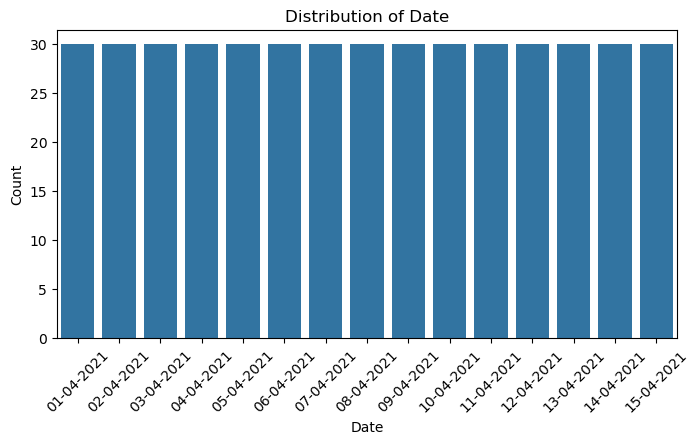

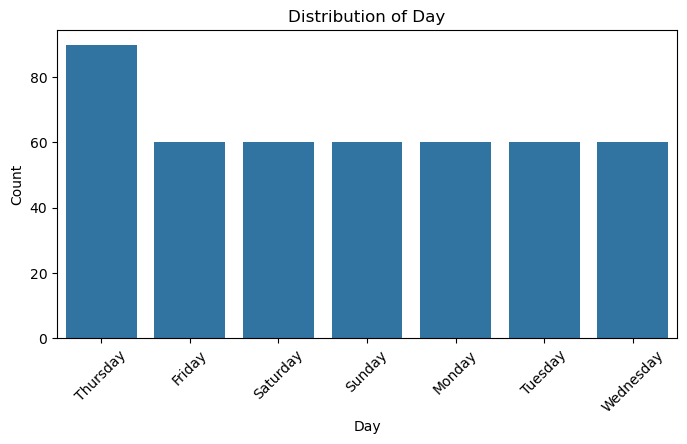

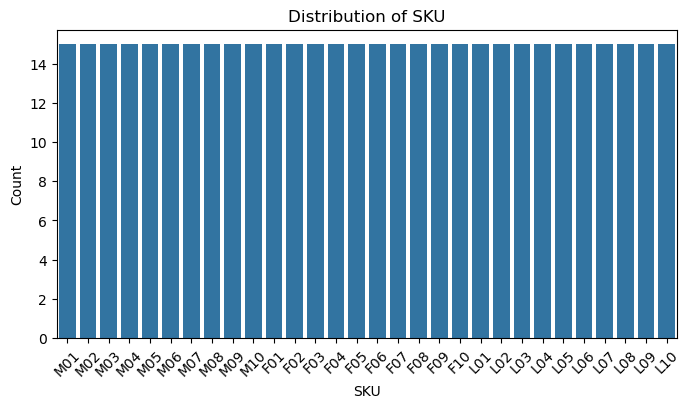

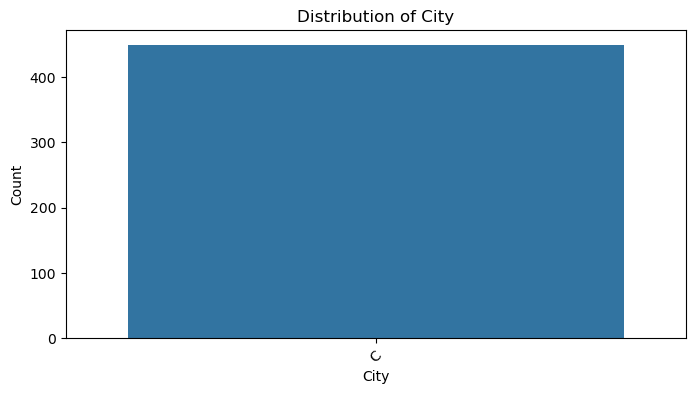

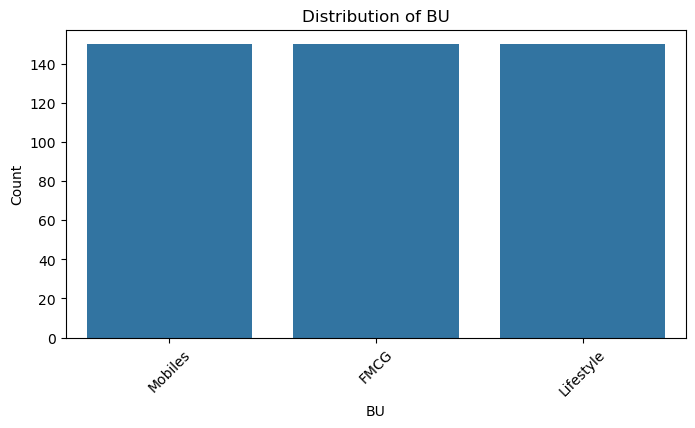

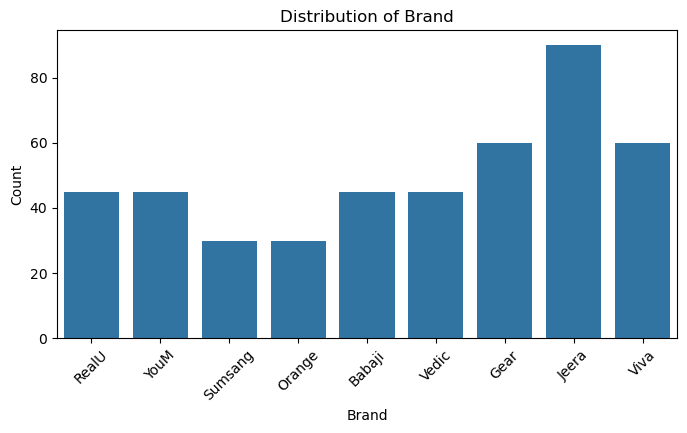

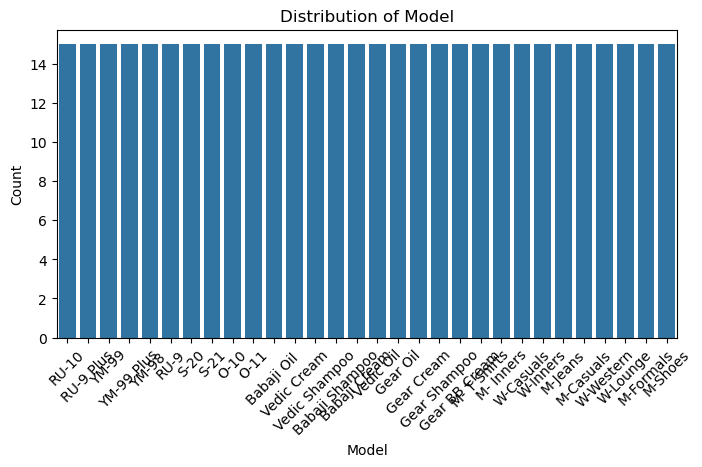

In [49]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

## Standardization of Numerical Variables

In [50]:
print("Volume\n")
standardized_copy=df.copy()
mean = df['Volume'].mean()
std = df['Volume'].std()
standardized_copy['Volume'] = (df['Volume']- mean) / std
print(standardized_copy['Volume'])


Volume

0      2.347417
1      1.165831
2      0.456880
3      0.220563
4     -0.488389
         ...   
445   -0.724706
446    0.220563
447   -0.724706
448   -0.488389
449   -0.961023
Name: Volume, Length: 450, dtype: float64


In [51]:
print("Avg Price\n")
standardized_copy=df.copy()
mean = df['Avg Price'].mean()
std = df['Avg Price'].std()
standardized_copy['Avg Price'] = (df['Avg Price']- mean) / std
print(standardized_copy['Avg Price'])

Avg Price

0      0.091072
1     -0.019548
2      0.312312
3      0.533552
4     -0.130168
         ...   
445   -0.506277
446   -0.434374
447   -0.489684
448   -0.473091
449   -0.406719
Name: Avg Price, Length: 450, dtype: float64


In [52]:
print("Total Sales Value\n")
standardized_copy=df.copy()
mean = df['Total Sales Value'].mean()
std = df['Total Sales Value'].std()
standardized_copy['Total Sales Value'] = (df['Total Sales Value']- mean) / std
print(standardized_copy['Total Sales Value'])

Total Sales Value

0      2.922469
1      1.329516
2      1.561038
3      1.717365
4     -0.188242
         ...   
445   -0.617647
446   -0.360400
447   -0.605774
448   -0.556303
449   -0.607753
Name: Total Sales Value, Length: 450, dtype: float64


In [53]:
print("Discount Amount\n")
standardized_copy=df.copy()
mean = df['Discount Amount'].mean()
std = df['Discount Amount'].std()
standardized_copy['Discount Amount'] = (df['Discount Amount']- mean) / std
print(standardized_copy['Discount Amount'])

Discount Amount

0      3.948422
1      1.846958
2      1.621190
3      1.112568
4      0.227598
         ...   
445   -0.652815
446   -0.152022
447   -0.607464
448   -0.529789
449   -0.636636
Name: Discount Amount, Length: 450, dtype: float64


In [54]:
print("Net Sales Value\n")
standardized_copy=df.copy()
mean = df['Net Sales Value'].mean()
std = df['Net Sales Value'].std()
standardized_copy['Net Sales Value'] = (df['Net Sales Value']- mean) / std
print(standardized_copy['Net Sales Value'])

Net Sales Value

0      2.801638
1      1.269613
2      1.543957
3      1.763847
4     -0.227342
         ...   
445   -0.609783
446   -0.378079
447   -0.601252
448   -0.554881
449   -0.600571
Name: Net Sales Value, Length: 450, dtype: float64


# Conversion of Categorical Data into Dummy Variables

In [55]:
categorical_cols = df.select_dtypes(include=["object","category"]).columns
print("Categorical Columns:", categorical_cols.tolist())

Categorical Columns: ['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


In [56]:
from sklearn.preprocessing import OneHotEncoder

In [57]:
categorical_cols=['Date','Day','SKU','City','BU','Brand','Model']
one_hot=OneHotEncoder(sparse_output=False)
encoded_array=one_hot.fit_transform(df[categorical_cols])
df1=pd.DataFrame(encoded_array,columns=one_hot.get_feature_names_out(categorical_cols))
df1.head()

,Date_01-04-2021,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,Date_05-04-2021,Date_06-04-2021,Date_07-04-2021,Date_08-04-2021,Date_09-04-2021,Date_10-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
